# 1. Research question

**Where does Hebbian learning remain useful, and where does BP credit assignment become necessary?**

This 3–5 minute walkthrough reads only the committed compact evidence in `release/v1.0-final/`. It does not load MNIST, checkpoints, raw representations, or the ignored local research archive. All displayed values come from frozen release tables.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from scripts.plot_final_figures import (
    COLORS, CORE_METHODS, configure_style, read_csv, verify_release
)

ROOT = Path.cwd().resolve()
assert (ROOT / 'release' / 'v1.0-final' / 'manifest.json').is_file()
release_manifest, _ = verify_release()
configure_style()
print(
    f"Compact release: PASS ({release_manifest['release_id']}) | "
    f"formal seeds: {release_manifest['formal_seeds']} | "
    f"test-access increment: {release_manifest['scientific_actions']['test_access_increment']}"
)

Compact release: PASS (v1.0-final) | formal seeds: [0, 1, 2, 3, 4] | test-access increment: 0


# 2. Method allocation

BBB uses BP throughout the encoder. HBB and HHB are hybrid models that begin BP at Enc2 or Enc3, respectively. HHH uses the competitive Oja/WTA Hebbian rule throughout the encoder. RBB/RRB are depth-matched random-prefix controls; Full Random is the overall lower bound.

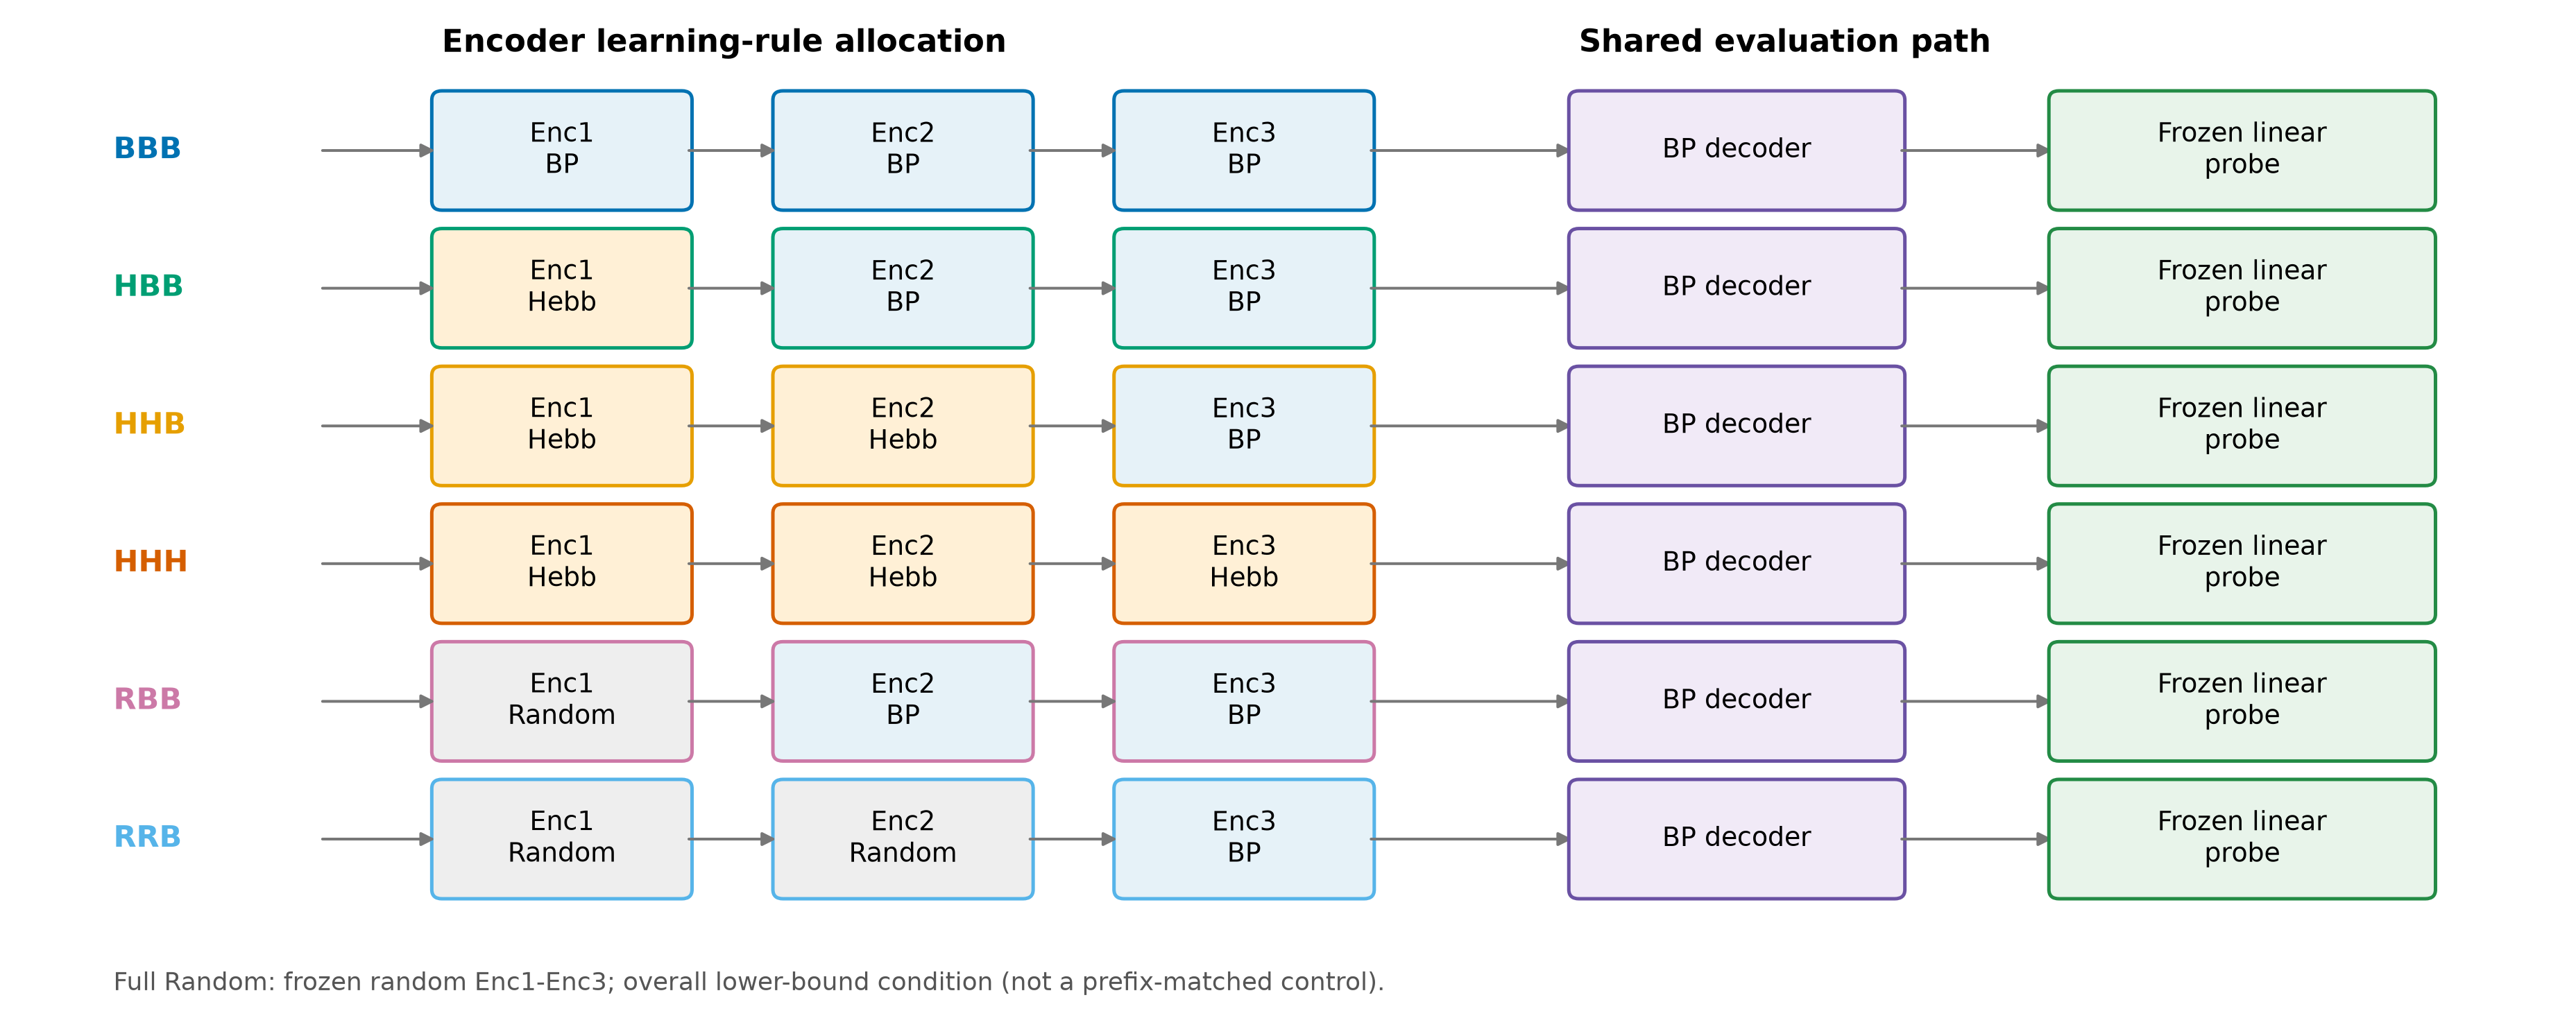

In [2]:
display(Image(filename=str(ROOT / 'figures' / 'final' / 'method_design.png'), width=1000))

# 3. Final performance

The first compact comparison places frozen linear probe accuracy beside standardized decoder reconstruction. The two metrics answer different questions and should be read together.

method  accuracy  standardized decoder MSE
 BBB    0.9158    0.003234
 HBB    0.9164    0.003312
 HHB    0.9199    0.004569
 HHH    0.8941    0.018689


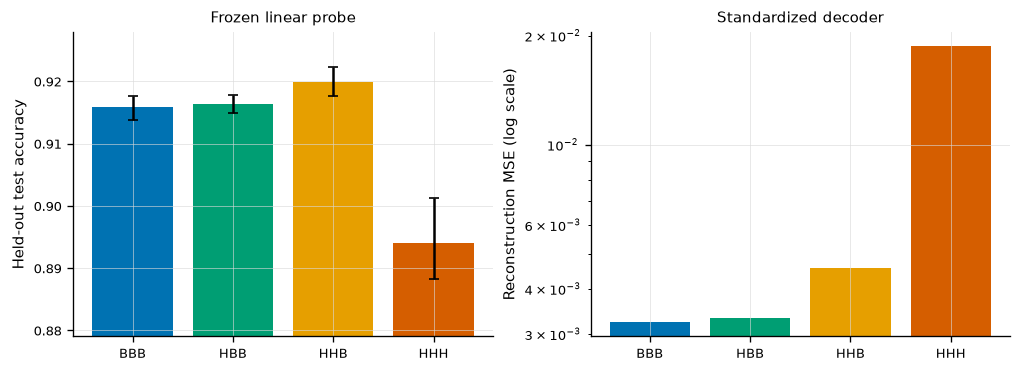

In [3]:
q1_rows = {row['method']: row for row in read_csv('data/q1/method_summary.csv')}
methods = list(CORE_METHODS)
accuracy = np.array([float(q1_rows[m]['accuracy_mean']) for m in methods])
accuracy_low = np.array([float(q1_rows[m]['accuracy_ci_low']) for m in methods])
accuracy_high = np.array([float(q1_rows[m]['accuracy_ci_high']) for m in methods])
standardized_mse = np.array([float(q1_rows[m]['standardized_reconstruction_mse_mean']) for m in methods])

print('method  accuracy  standardized decoder MSE')
for method, acc, mse in zip(methods, accuracy, standardized_mse):
    print(f'{method:>4}    {acc:.4f}    {mse:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.0), constrained_layout=True)
x = np.arange(len(methods))
axes[0].bar(methods, accuracy, color=[COLORS[m] for m in methods])
axes[0].errorbar(x, accuracy, yerr=[accuracy - accuracy_low, accuracy_high - accuracy], fmt='none', color='black', capsize=3)
axes[0].set_ylim(max(0, accuracy.min() - 0.015), min(1, accuracy.max() + 0.008))
axes[0].set_ylabel('Held-out test accuracy')
axes[0].set_title('Frozen linear probe')
axes[1].bar(methods, standardized_mse, color=[COLORS[m] for m in methods])
axes[1].set_yscale('log')
axes[1].set_ylabel('Reconstruction MSE (log scale)')
axes[1].set_title('Standardized decoder')
display(fig)
plt.close(fig)

# 4. Layerwise representation

Effective rank tracks how representation variance is distributed across dimensions. It is not a direct measure of semantic information. The h1 → h2 → z trajectory is the central notebook view.

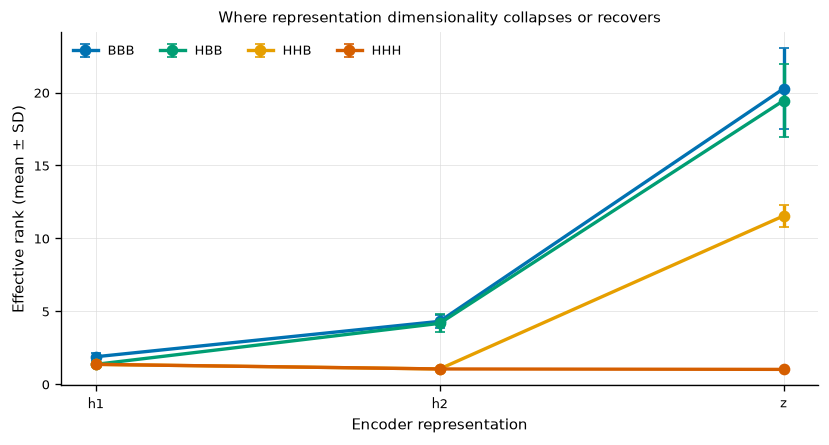

z effective rank loaded from the compact Q2 table:
BBB: 20.269
HBB: 19.450
HHB: 11.541
HHH: 1.016


In [4]:
q2_rows = read_csv('data/q2/method_layer_summary.csv')
q2 = {(row['method'], row['layer']): row for row in q2_rows}
layers = ['h1', 'h2', 'z']

fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)
for method in methods:
    rank = np.array([float(q2[(method, layer)]['effective_rank_mean']) for layer in layers])
    rank_sd = np.array([float(q2[(method, layer)]['effective_rank_sd']) for layer in layers])
    ax.errorbar(layers, rank, yerr=rank_sd, marker='o', linewidth=2, capsize=3, label=method, color=COLORS[method])
ax.set_ylabel('Effective rank (mean ± SD)')
ax.set_xlabel('Encoder representation')
ax.set_title('Where representation dimensionality collapses or recovers')
ax.legend(ncol=4, loc='upper left')
display(fig)
plt.close(fig)

print('z effective rank loaded from the compact Q2 table:')
for method in methods:
    print(f"{method}: {float(q2[(method, 'z')]['effective_rank_mean']):.3f}")

# 5. Update mechanism

The accepted HHH effective Hebbian update is compared with the matched BP reconstruction direction at the same layer, snapshot, and fixed batches. Alignment is a mechanistic association, not strict causal proof or a claim that BP is universally optimal.

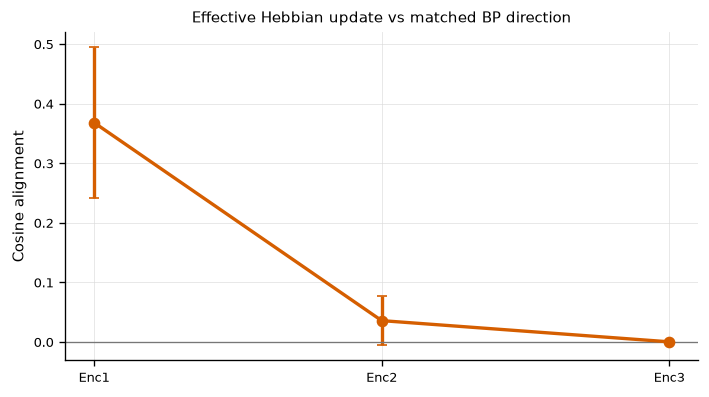

layer  alignment  scale-matched bias  linear SNR
enc1    0.36801            0.921372    453.0918
enc2    0.03563            0.998687      0.0181
enc3    0.00005            1.000000      1.2933


In [5]:
q4_rows = [
    row for row in read_csv('data/q4/method_layer_update_summary.csv')
    if row['method'] == 'HHH' and row['rule'] == 'hebbian_effective'
]
layer_order = {'enc1': 0, 'enc2': 1, 'enc3': 2}
q4_rows.sort(key=lambda row: layer_order[row['layer']])
alignment = np.array([float(row['alignment_mean']) for row in q4_rows])
alignment_sd = np.array([float(row['alignment_sd']) for row in q4_rows])

fig, ax = plt.subplots(figsize=(5.8, 3.2), constrained_layout=True)
ax.errorbar(['Enc1', 'Enc2', 'Enc3'], alignment, yerr=alignment_sd, marker='o', linewidth=2, capsize=3, color=COLORS['HHH'])
ax.axhline(0, color='#777777', linewidth=0.8)
ax.set_ylabel('Cosine alignment')
ax.set_title('Effective Hebbian update vs matched BP direction')
display(fig)
plt.close(fig)

print('layer  alignment  scale-matched bias  linear SNR')
for row in q4_rows:
    print(
        f"{row['layer']:>4}  {float(row['alignment_mean']):9.5f}"
        f"  {float(row['scale_matched_bias_mean']):18.6f}"
        f"  {float(row['update_snr_linear_mean']):10.4f}"
    )

# 6. Robustness

These curves evaluate clean-trained frozen models under three corruptions. They are not adversarial robustness results and do not represent noisy training.

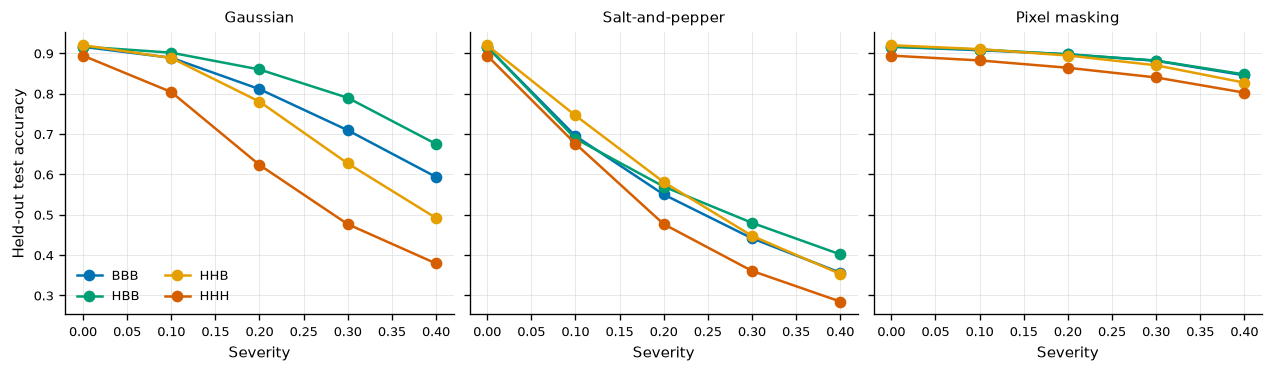

In [6]:
q3_rows = read_csv('data/q3/condition_summary.csv')
noise_types = [('gaussian', 'Gaussian'), ('salt_pepper', 'Salt-and-pepper'), ('pixel_masking', 'Pixel masking')]
clean = {row['method']: row for row in q3_rows if row['noise_type'] == 'clean'}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), sharey=True, constrained_layout=True)
for ax, (noise, label) in zip(axes, noise_types):
    for method in methods:
        noisy = sorted(
            [row for row in q3_rows if row['method'] == method and row['noise_type'] == noise],
            key=lambda row: float(row['severity']),
        )
        severity = [0.0] + [float(row['severity']) for row in noisy]
        values = [float(clean[method]['accuracy_mean'])] + [float(row['accuracy_mean']) for row in noisy]
        ax.plot(severity, values, marker='o', label=method, color=COLORS[method])
    ax.set_title(label)
    ax.set_xlabel('Severity')
axes[0].set_ylabel('Held-out test accuracy')
axes[0].legend(ncol=2, loc='lower left')
display(fig)
plt.close(fig)

# 7. Final takeaways

1. Shallow Hebbian prefixes retain useful classification information.
2. Fully local deep stacking produces severe low-dimensional compression under this tested rule.
3. BP restores representation dimensionality at the layer where it is introduced, with earlier intervention improving broader system behavior.